# 4 &middot; Swath edges in real retrievals: NaN vs grid edge

Real GPM L2 data is a **NaN-masked band**: the instrument's cross-track edge is where the numbers turn to NaN, while the *array* edge is just the along-track time cut (or a regional crop) &mdash; the satellite saw straight through it. So a feature touching the top row of the array has **not** reached a swath edge.

`gridfeatures` makes this a switch:

* `boundary_pixels` / `touches_boundary` (`count_grid_edge=True`) &mdash; NaN *or* array edge. Right for a closed model domain.
* `cross_track_edge_pixels` / `touches_cross_track_edge` (`count_grid_edge=False`) &mdash; NaN only. Right for satellite swath crops.


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Kilometres per degree (same constant the package uses for its tangent plane).
KM_PER_DEG = math.pi * 6371.0 / 180.0


def add_ellipse(field, lat2d, lon2d, clat, clon, a_deg, b_deg, angle_deg, val):
    """Paint an elliptical blob (value `val`) into `field`.

    `a_deg`/`b_deg` are the semi-axes; longitude offsets are scaled by
    cos(clat) so the blob is round in ground distance, not in raw degrees.
    `angle_deg` tilts the major axis counterclockwise from east.
    """
    th = math.radians(angle_deg)
    dy = lat2d - clat
    dx = (lon2d - clon) * math.cos(math.radians(clat))
    xr = dx * math.cos(th) + dy * math.sin(th)
    yr = -dx * math.sin(th) + dy * math.cos(th)
    field[(xr / a_deg) ** 2 + (yr / b_deg) ** 2 <= 1.0] = val


def fitted_ellipse_lonlat(f, lat0, lon0, n=240):
    """Trace the package's fitted ellipse for feature `f` in lon/lat.

    Uses the public shape stats (major/minor axis km + orientation) and a
    supplied centre, so it draws exactly what `gridfeatures` measured.
    """
    from gridfeatures import stats
    a = stats.major_axis_km(f)
    b = stats.minor_axis_km(f)
    th = math.radians(stats.orientation_deg(f))
    t = np.linspace(0, 2 * np.pi, n)
    xk, yk = (a / 2) * np.cos(t), (b / 2) * np.sin(t)
    xr = xk * math.cos(th) - yk * math.sin(th)
    yr = xk * math.sin(th) + yk * math.cos(th)
    lon = lon0 + xr / (KM_PER_DEG * math.cos(math.radians(lat0)))
    lat = lat0 + yr / KM_PER_DEG
    return lon, lat


## A synthetic swath band with three features

Observed cells (value `0`, then features at `5`) fill a vertical band; everything else is NaN. We plant one feature against the band's NaN edge (a real cross-track edge), one on the array's top row but *interior* to the band (an along-track cap), and one fully interior.

In [2]:
from gridfeatures import stats
from gridfeatures.stats import _boundary_mask
from gridfeatures.config import Config
from gridfeatures.runner import extract_features

n = 16
field = np.full((n, n), np.nan)
field[:, 5:11] = 0.0        # observed band (cols 5-10); outside is NaN
field[0:2, 6:9] = 5.0       # 'cap'      : top array rows, interior to the band
field[7:9, 5:7] = 5.0       # 'west edge': hard against the NaN column 4
field[11:13, 7:9] = 5.0     # 'interior' : no NaN, no array edge nearby

lat = np.arange(n, dtype=float)     # plain indices; geography is irrelevant here
lon = np.arange(n, dtype=float)
lats2d, lons2d = np.meshgrid(lat, lon, indexing="ij")

cfg = Config(files="mem", variable="x", threshold=1.0, statistics={"size": stats.size})
feats = extract_features(field, lats2d, lons2d, cfg, source="mem")

def name_of(f):
    if f.rows.min() == 0:      return "cap"
    if f.cols.min() == 5:      return "west edge"
    return "interior"

for f in sorted(feats, key=lambda f: f.rows.min()):
    print(f"{name_of(f):10s} boundary_px={stats.boundary_pixels(f):2d}  "
          f"cross_track_px={stats.cross_track_edge_pixels(f):2d}  "
          f"touches_cross_track={stats.touches_cross_track_edge(f)}")

cap        boundary_px= 3  cross_track_px= 0  touches_cross_track=False
west edge  boundary_px= 2  cross_track_px= 2  touches_cross_track=True
interior   boundary_px= 0  cross_track_px= 0  touches_cross_track=False


The **cap** shows `boundary_px > 0` but `cross_track_px = 0`: it touches the array edge but no NaN, so it is *not* at a swath edge. The **west edge** feature borders NaN, so both agree. The **interior** feature counts zero either way.

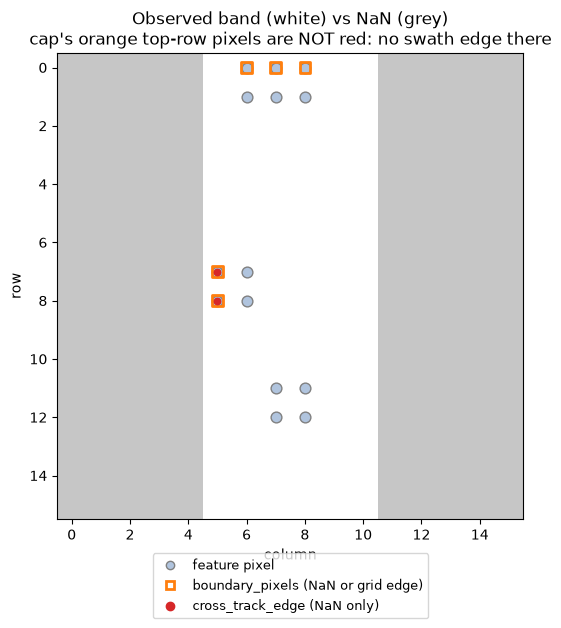

In [3]:
fig, ax = plt.subplots(figsize=(6.6, 6.4))
# background: NaN cells grey, observed band white
ax.imshow(np.isnan(field).astype(float), cmap="Greys", vmin=0, vmax=3, origin="upper")

for f in feats:
    grid_edge = _boundary_mask(f, count_grid_edge=True)    # NaN or array edge
    nan_edge = _boundary_mask(f, count_grid_edge=False)    # NaN only
    ax.scatter(f.cols, f.rows, s=60, c="lightsteelblue", edgecolors="grey", label=None)
    ax.scatter(f.cols[grid_edge], f.rows[grid_edge], s=60, marker="s",
               facecolors="none", edgecolors="tab:orange", lw=2)
    ax.scatter(f.cols[nan_edge], f.rows[nan_edge], s=22, c="tab:red")

from matplotlib.lines import Line2D
handles = [
    Line2D([], [], marker="o", ls="", mfc="lightsteelblue", mec="grey", label="feature pixel"),
    Line2D([], [], marker="s", ls="", mfc="none", mec="tab:orange", mew=2, label="boundary_pixels (NaN or grid edge)"),
    Line2D([], [], marker="o", ls="", mfc="tab:red", mec="tab:red", label="cross_track_edge (NaN only)"),
]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.06), ncol=1, fontsize=9)
ax.set_title("Observed band (white) vs NaN (grey)\n"
             "cap's orange top-row pixels are NOT red: no swath edge there")
ax.set_xlabel("column"); ax.set_ylabel("row")
plt.tight_layout(); plt.show()

## `legacy_is_complete`: bounding box, not pixels

The prior GPM codebase flagged a feature incomplete if any swath-edge cell fell inside its **bounding box** &mdash; even a cell that is not a member of the feature. `gridfeatures.stats.legacy_is_complete` reproduces that exactly, for validation. Here an L-shaped feature is *complete* by the honest pixel-contact test yet *incomplete* by the legacy bbox test.

In [4]:
field2 = np.zeros((4, 6))
field2[0, 4] = np.nan                        # a NaN inside the bbox, off the feature
for r, c in [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (2, 3)]:
    field2[r, c] = 5.0                       # the L
lat2 = np.arange(4.0); lon2 = np.arange(6.0)
l2, o2 = np.meshgrid(lat2, lon2, indexing="ij")
g = extract_features(field2, l2, o2, cfg, source="mem")[0]

print("bounding box (r0,r1,c0,c1) :", g.bbox)
print("touches_cross_track_edge   :", stats.touches_cross_track_edge(g), " (no feature pixel borders NaN)")
print("legacy_is_complete         :", stats.legacy_is_complete(g), " (a NaN sits inside the bbox)")
assert stats.touches_cross_track_edge(g) is False
assert stats.legacy_is_complete(g) is False
print("\nBoth definitions behave as documented -- prefer the pixel-contact test for new work.")

bounding box (r0,r1,c0,c1) : (0, 3, 0, 4)
touches_cross_track_edge   : False  (no feature pixel borders NaN)
legacy_is_complete         : False  (a NaN sits inside the bbox)

Both definitions behave as documented -- prefer the pixel-contact test for new work.
